In [ ]:
!pip install opensignalsreader biosppy peakutils


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 kB 4.2 MB/s eta 0:00:00


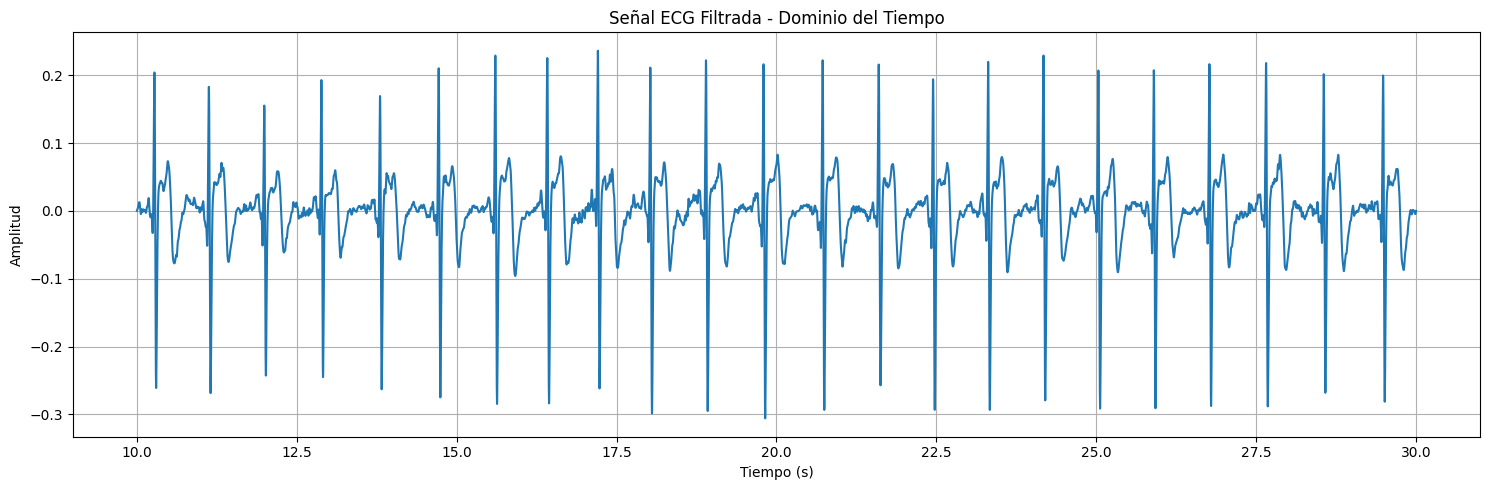

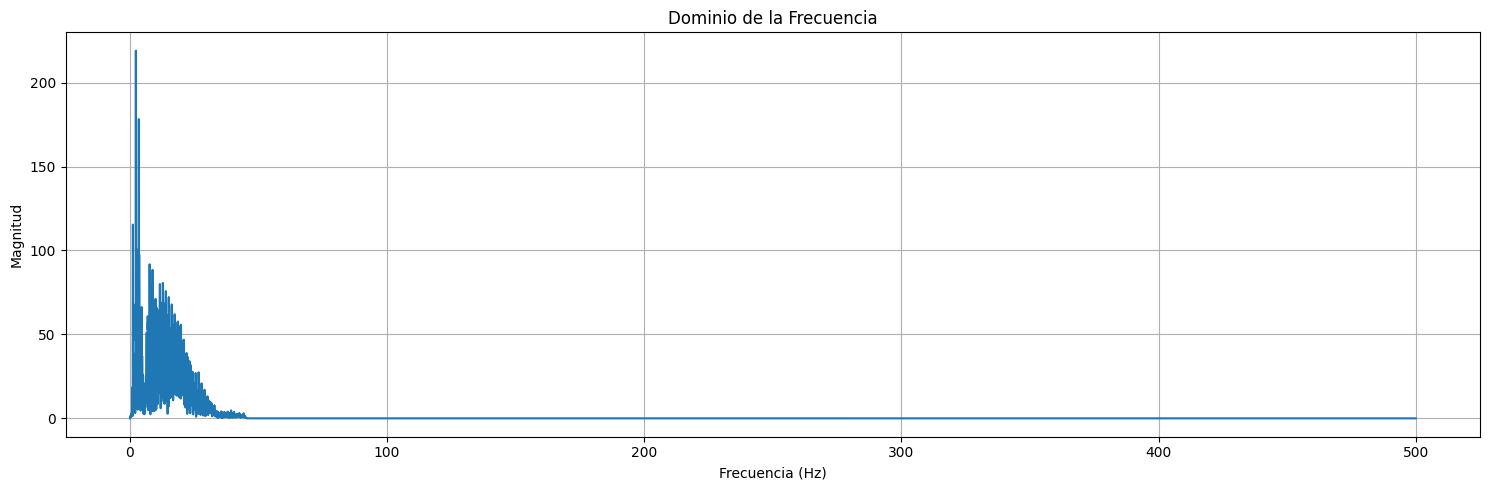

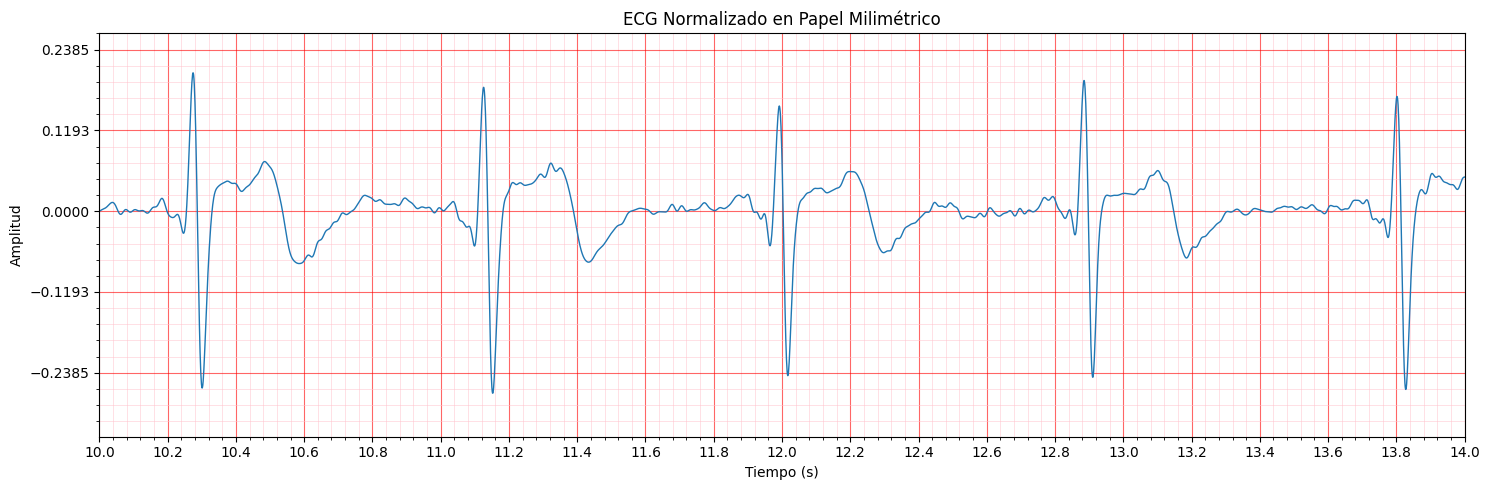

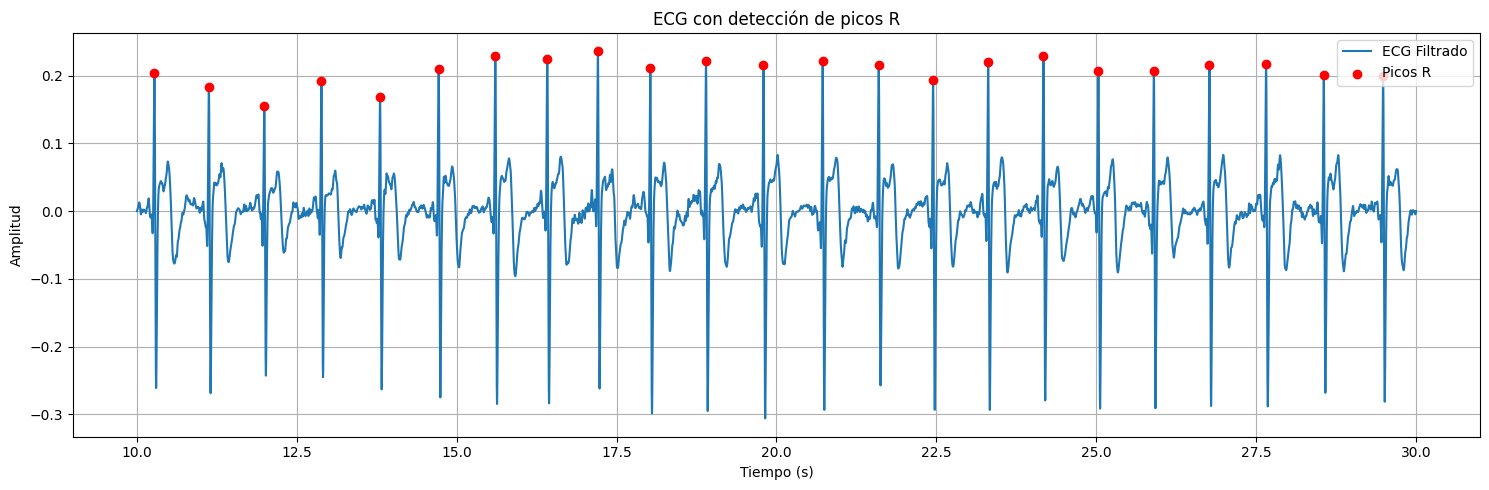

Frecuencia cardíaca promedio: 68.83 BPM


In [ ]:
# Importar librerías
import numpy as np
import matplotlib.pyplot as plt
from opensignalsreader import OpenSignalsReader
from biosppy.signals import ecg

# Ruta del archivo subido
archivo = '/content/E1-señalbasal-D1-final.txt'

# Leer archivo
ekg = OpenSignalsReader(archivo)

# Extraer señal del canal 2
ekg_signal = ekg.signal(2)

# Frecuencia de muestreo
fs = 1000  # Hz

# Limitar tiempo
idx_10 = int(10 * fs)
idx_30 = int(30 * fs)

# Crear vector de tiempo
tiempo = np.arange(len(ekg_signal)) / fs

tiempo_basal = tiempo[idx_10:idx_30]
ekg_signal_basal = ekg_signal[idx_10:idx_30]

# Procesamiento ECG
ecg_out = ecg.ecg(signal=ekg_signal_basal, sampling_rate=fs, show=False)

# Señal filtrada
ekg_filtrado = ecg_out['filtered']

# FFT
ekg_centrado = ekg_filtrado - np.mean(ekg_filtrado)
freq_basal = np.fft.rfftfreq(len(ekg_filtrado), d=1/fs)
esp_basal = np.abs(np.fft.rfft(ekg_centrado))

# --------- Plot dominio del tiempo ----------
plt.figure(figsize=(15,5))
plt.plot(tiempo_basal, ekg_filtrado)
plt.title('Señal ECG Filtrada - Dominio del Tiempo')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.tight_layout()
plt.show()

# --------- FFT ----------
plt.figure(figsize=(15,5))
plt.plot(freq_basal, esp_basal)
plt.title('Dominio de la Frecuencia')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.grid(True)
plt.tight_layout()
plt.show()

# --------- Plot ECG estilo milimétrico ----------
plt.figure(figsize=(15,5))
plt.plot(tiempo_basal, ekg_filtrado, linewidth=1)

plt.xlim(10,14)

# Cuadrícula tipo papel ECG
plt.minorticks_on()
plt.grid(which='major', color='red', linestyle='-', linewidth=0.8, alpha=0.6)
plt.grid(which='minor', color='pink', linestyle='-', linewidth=0.5, alpha=0.7)

# Escala milimétrica típica ECG:
plt.gca().xaxis.set_minor_locator(plt.MultipleLocator(0.04))  # 1 mm = 0.04 s
plt.gca().xaxis.set_major_locator(plt.MultipleLocator(0.20))  # 5 mm = 0.20 s

# Ajuste vertical aproximado (depende de calibración real)
ymin, ymax = plt.ylim()
yrange = ymax - ymin
plt.gca().yaxis.set_minor_locator(plt.MultipleLocator(yrange/25))
plt.gca().yaxis.set_major_locator(plt.MultipleLocator(yrange/5))

plt.title('ECG Normalizado en Papel Milimétrico')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.tight_layout()
plt.show()

# Procesamiento ECG
out = ecg.ecg(signal=ekg_signal_basal, sampling_rate=fs, show=False)

# Señal filtrada y picos R
ekg_filtrado = out['filtered']
rpeaks = out['rpeaks']

# Graficar con picos
plt.figure(figsize=(15,5))
plt.plot(tiempo_basal, ekg_filtrado, label='ECG Filtrado')
plt.scatter(
    tiempo_basal[rpeaks],
    ekg_filtrado[rpeaks],
    color='red',
    label='Picos R',
    zorder=3
)

plt.title('ECG con detección de picos R')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Tiempos de picos R
tiempos_r = tiempo_basal[rpeaks]

# Intervalos RR y frecuencia cardíaca
rr_intervals = np.diff(tiempos_r)
hr = 60 / rr_intervals
hr_promedio = np.mean(hr)

print(f'Frecuencia cardíaca promedio: {hr_promedio:.2f} BPM')

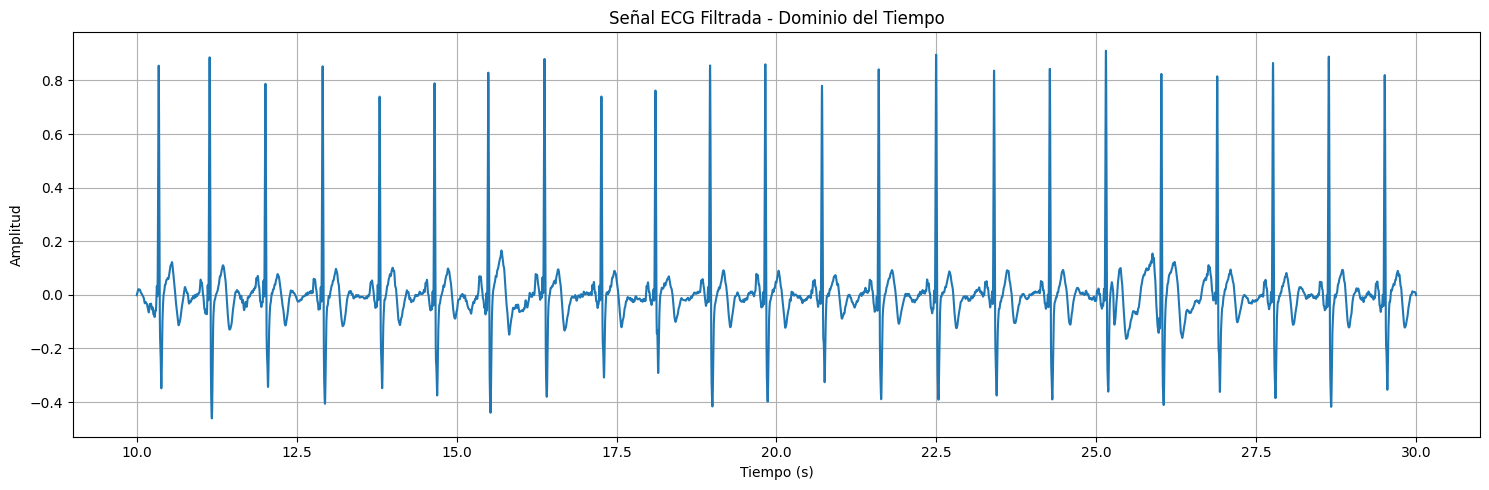

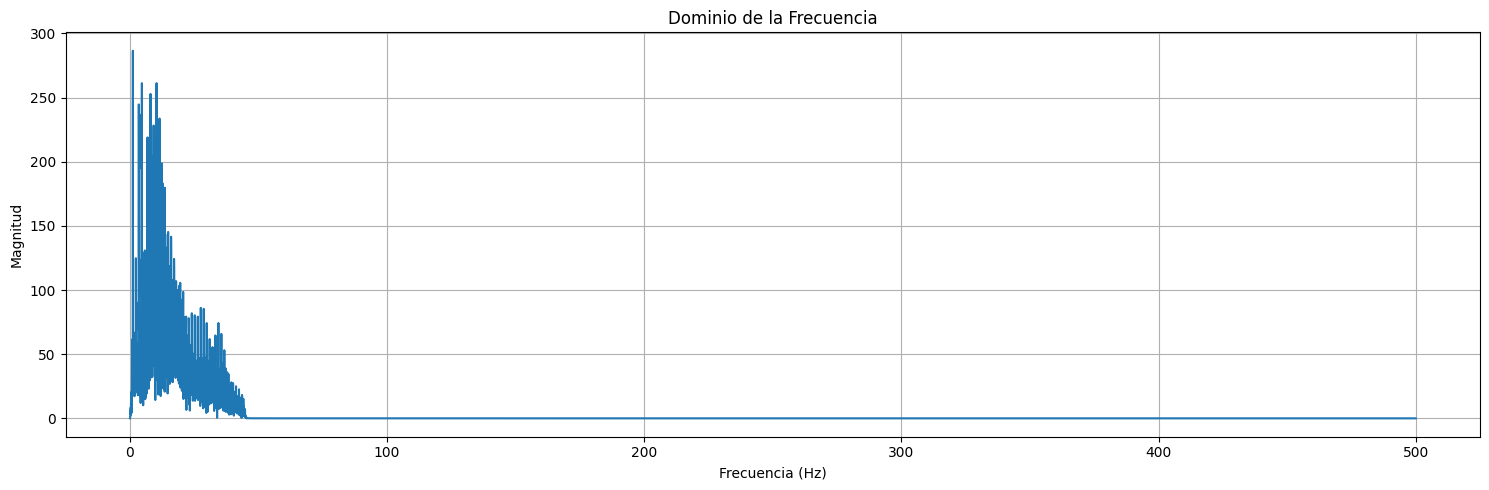

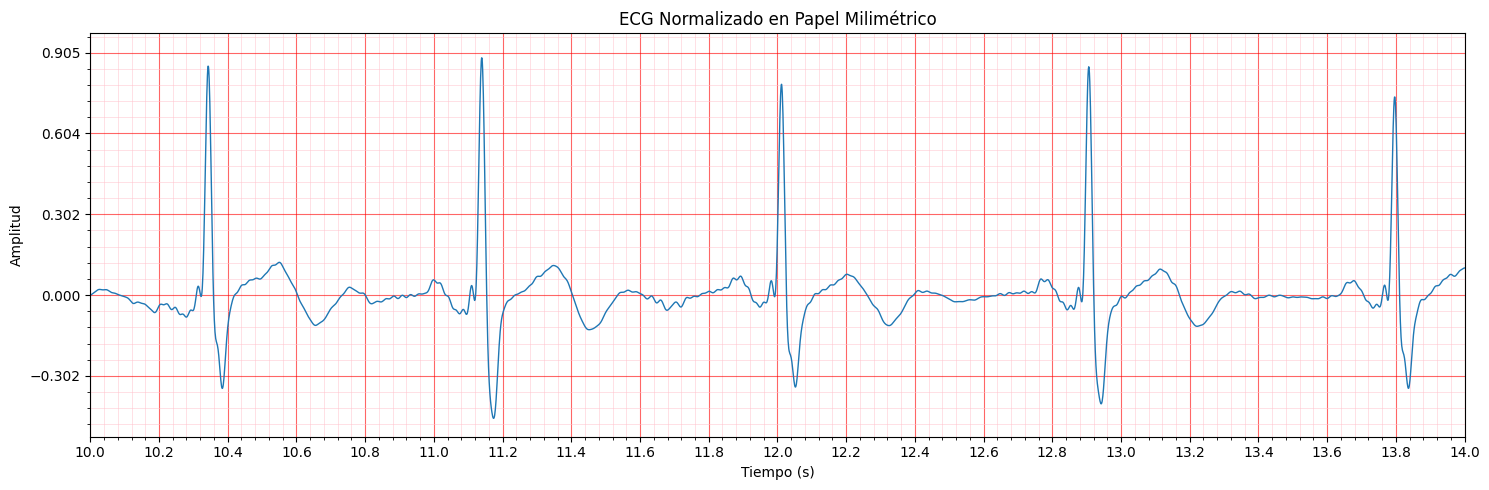

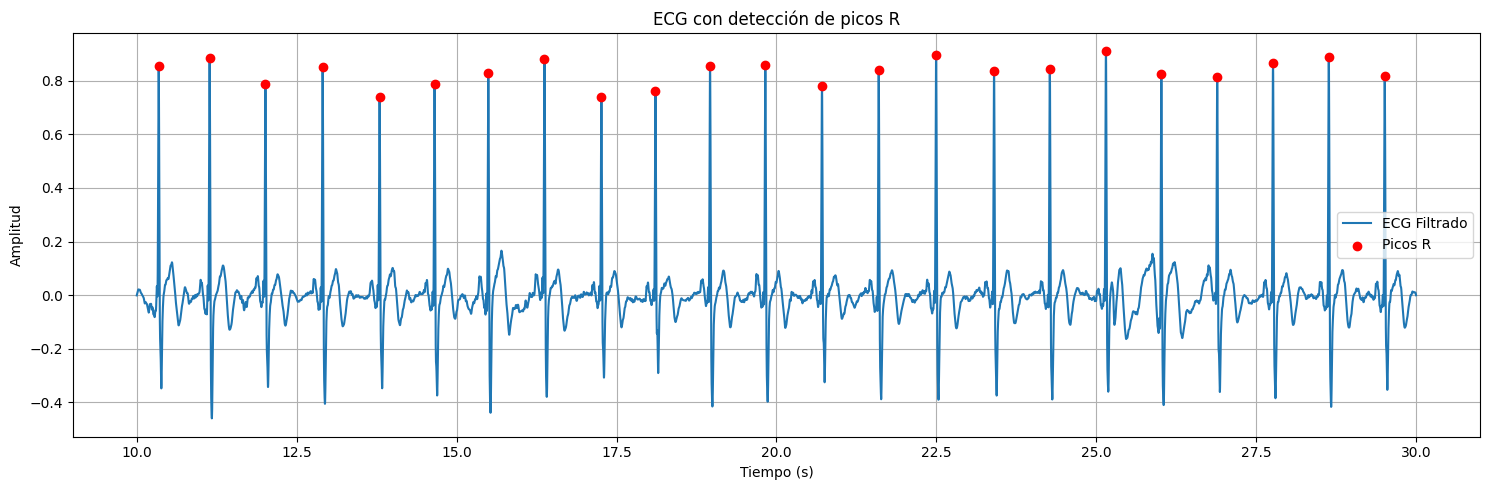

Frecuencia cardíaca promedio: 68.92 BPM


In [5]:
# Ruta del archivo subido
archivo = '/content/E1-señalbasal-D2-final.txt'

# Leer archivo
ekg = OpenSignalsReader(archivo)

# Extraer señal del canal 2
ekg_signal = ekg.signal(2)

# Frecuencia de muestreo
fs = 1000  # Hz

# Limitar tiempo
idx_10 = int(10 * fs)
idx_30 = int(30 * fs)

# Crear vector de tiempo
tiempo = np.arange(len(ekg_signal)) / fs

tiempo_basal = tiempo[idx_10:idx_30]
ekg_signal_basal = ekg_signal[idx_10:idx_30]

# Procesamiento ECG
ecg_out = ecg.ecg(signal=ekg_signal_basal, sampling_rate=fs, show=False)

# Señal filtrada
ekg_filtrado = ecg_out['filtered']

# FFT
ekg_centrado = ekg_filtrado - np.mean(ekg_filtrado)
freq_basal = np.fft.rfftfreq(len(ekg_filtrado), d=1/fs)
esp_basal = np.abs(np.fft.rfft(ekg_centrado))

# --------- Plot dominio del tiempo ----------
plt.figure(figsize=(15,5))
plt.plot(tiempo_basal, ekg_filtrado)
plt.title('Señal ECG Filtrada - Dominio del Tiempo')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.tight_layout()
plt.show()

# --------- FFT ----------
plt.figure(figsize=(15,5))
plt.plot(freq_basal, esp_basal)
plt.title('Dominio de la Frecuencia')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.grid(True)
plt.tight_layout()
plt.show()

# --------- Plot ECG estilo milimétrico ----------
plt.figure(figsize=(15,5))
plt.plot(tiempo_basal, ekg_filtrado, linewidth=1)

plt.xlim(10,14)

# Cuadrícula tipo papel ECG
plt.minorticks_on()
plt.grid(which='major', color='red', linestyle='-', linewidth=0.8, alpha=0.6)
plt.grid(which='minor', color='pink', linestyle='-', linewidth=0.5, alpha=0.7)

# Escala milimétrica típica ECG:
plt.gca().xaxis.set_minor_locator(plt.MultipleLocator(0.04))  # 1 mm = 0.04 s
plt.gca().xaxis.set_major_locator(plt.MultipleLocator(0.20))  # 5 mm = 0.20 s

# Ajuste vertical aproximado (depende de calibración real)
ymin, ymax = plt.ylim()
yrange = ymax - ymin
plt.gca().yaxis.set_minor_locator(plt.MultipleLocator(yrange/25))
plt.gca().yaxis.set_major_locator(plt.MultipleLocator(yrange/5))

plt.title('ECG Normalizado en Papel Milimétrico')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.tight_layout()
plt.show()

# Procesamiento ECG
out = ecg.ecg(signal=ekg_signal_basal, sampling_rate=fs, show=False)

# Señal filtrada y picos R
ekg_filtrado = out['filtered']
rpeaks = out['rpeaks']

# Graficar con picos
plt.figure(figsize=(15,5))
plt.plot(tiempo_basal, ekg_filtrado, label='ECG Filtrado')
plt.scatter(
    tiempo_basal[rpeaks],
    ekg_filtrado[rpeaks],
    color='red',
    label='Picos R',
    zorder=3
)

plt.title('ECG con detección de picos R')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Tiempos de picos R
tiempos_r = tiempo_basal[rpeaks]

# Intervalos RR y frecuencia cardíaca
rr_intervals = np.diff(tiempos_r)
hr = 60 / rr_intervals
hr_promedio = np.mean(hr)

print(f'Frecuencia cardíaca promedio: {hr_promedio:.2f} BPM')

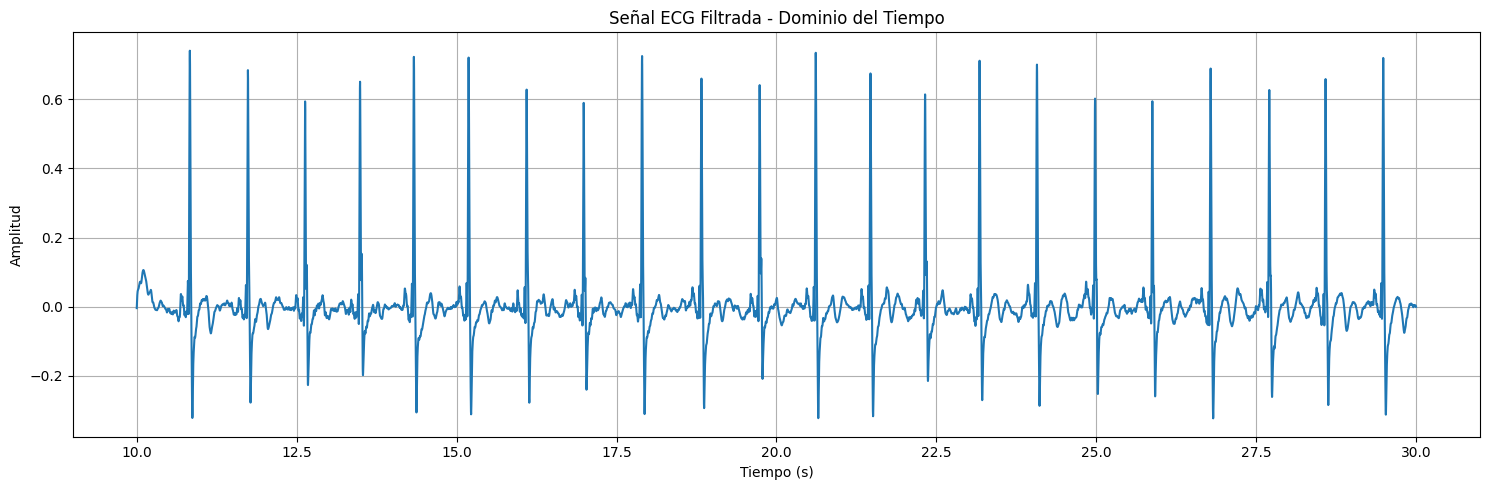

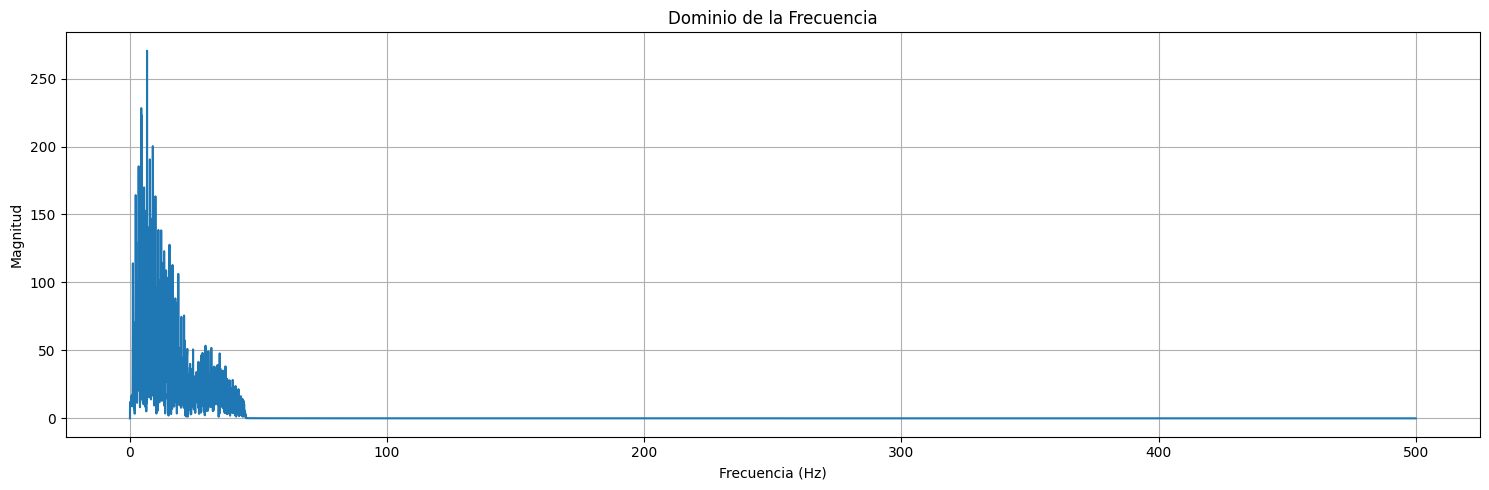

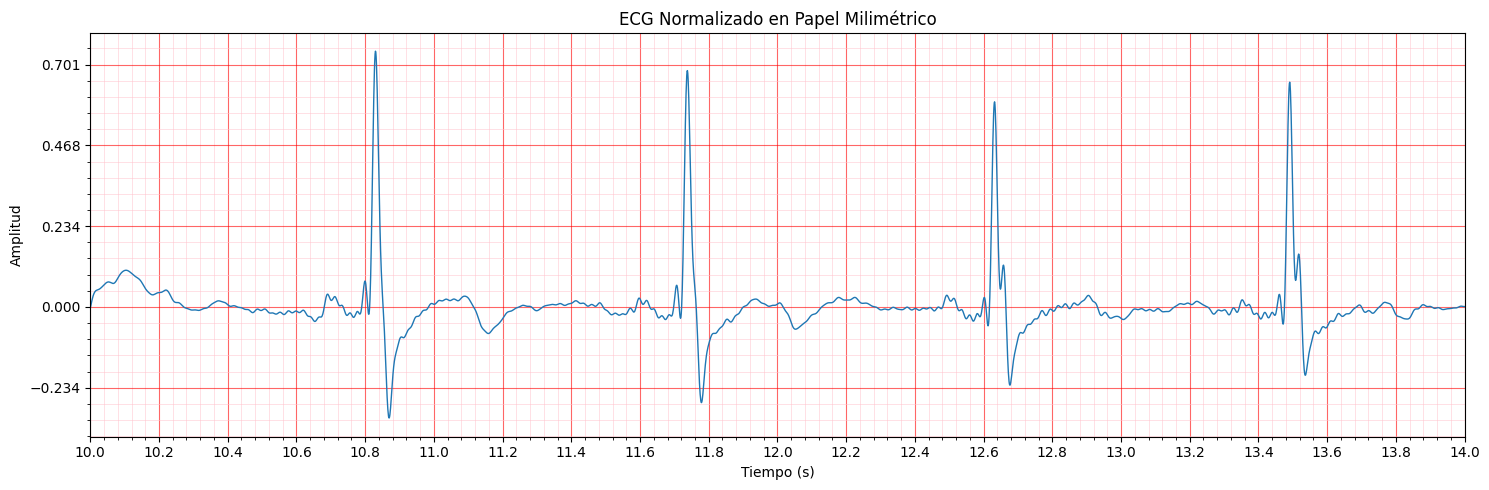

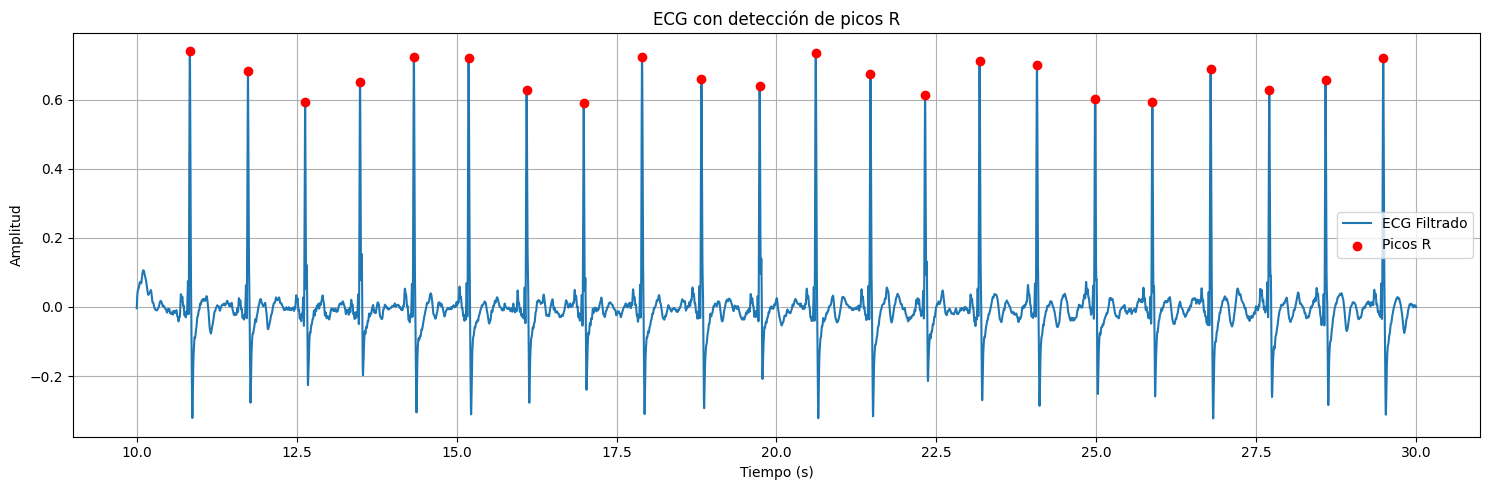

Frecuencia cardíaca promedio: 67.59 BPM


In [7]:
# Ruta del archivo subido
archivo = '/content/E1-señalbasal-D3-final.txt'

# Leer archivo
ekg = OpenSignalsReader(archivo)

# Extraer señal del canal 2
ekg_signal = ekg.signal(2)

# Frecuencia de muestreo
fs = 1000  # Hz

# Limitar tiempo
idx_10 = int(10 * fs)
idx_30 = int(30 * fs)

# Crear vector de tiempo
tiempo = np.arange(len(ekg_signal)) / fs

tiempo_basal = tiempo[idx_10:idx_30]
ekg_signal_basal = ekg_signal[idx_10:idx_30]

# Procesamiento ECG
ecg_out = ecg.ecg(signal=ekg_signal_basal, sampling_rate=fs, show=False)

# Señal filtrada
ekg_filtrado = ecg_out['filtered']

# FFT
ekg_centrado = ekg_filtrado - np.mean(ekg_filtrado)
freq_basal = np.fft.rfftfreq(len(ekg_filtrado), d=1/fs)
esp_basal = np.abs(np.fft.rfft(ekg_centrado))

# --------- Plot dominio del tiempo ----------
plt.figure(figsize=(15,5))
plt.plot(tiempo_basal, ekg_filtrado)
plt.title('Señal ECG Filtrada - Dominio del Tiempo')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.tight_layout()
plt.show()

# --------- FFT ----------
plt.figure(figsize=(15,5))
plt.plot(freq_basal, esp_basal)
plt.title('Dominio de la Frecuencia')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.grid(True)
plt.tight_layout()
plt.show()

# --------- Plot ECG estilo milimétrico ----------
plt.figure(figsize=(15,5))
plt.plot(tiempo_basal, ekg_filtrado, linewidth=1)

plt.xlim(10,14)

# Cuadrícula tipo papel ECG
plt.minorticks_on()
plt.grid(which='major', color='red', linestyle='-', linewidth=0.8, alpha=0.6)
plt.grid(which='minor', color='pink', linestyle='-', linewidth=0.5, alpha=0.7)

# Escala milimétrica típica ECG:
plt.gca().xaxis.set_minor_locator(plt.MultipleLocator(0.04))  # 1 mm = 0.04 s
plt.gca().xaxis.set_major_locator(plt.MultipleLocator(0.20))  # 5 mm = 0.20 s

# Ajuste vertical aproximado (depende de calibración real)
ymin, ymax = plt.ylim()
yrange = ymax - ymin
plt.gca().yaxis.set_minor_locator(plt.MultipleLocator(yrange/25))
plt.gca().yaxis.set_major_locator(plt.MultipleLocator(yrange/5))

plt.title('ECG Normalizado en Papel Milimétrico')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.tight_layout()
plt.show()

# Procesamiento ECG
out = ecg.ecg(signal=ekg_signal_basal, sampling_rate=fs, show=False)

# Señal filtrada y picos R
ekg_filtrado = out['filtered']
rpeaks = out['rpeaks']

# Graficar con picos
plt.figure(figsize=(15,5))
plt.plot(tiempo_basal, ekg_filtrado, label='ECG Filtrado')
plt.scatter(
    tiempo_basal[rpeaks],
    ekg_filtrado[rpeaks],
    color='red',
    label='Picos R',
    zorder=3
)

plt.title('ECG con detección de picos R')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Tiempos de picos R
tiempos_r = tiempo_basal[rpeaks]

# Intervalos RR y frecuencia cardíaca
rr_intervals = np.diff(tiempos_r)
hr = 60 / rr_intervals
hr_promedio = np.mean(hr)

print(f'Frecuencia cardíaca promedio: {hr_promedio:.2f} BPM')